# Day 04. 손실함수와 이진분류

## 1) 오늘의 학습 목표

- MSE와 MAE의 차이를 이상치 관점에서 짧게 비교한다.
- sigmoid와 BCE를 사용해 이진분류 모델을 학습한다.
- PyTorch의 `BCEWithLogitsLoss`로 작은 선형 이진분류 모델을 학습한다.
- threshold를 기준으로 확률을 0/1 예측으로 바꾸고 평가 지표를 계산한다.


## 2) 손실 함수(Loss Function)

* 손실함수는 모델이 얼마나 틀렸는지 숫자로 알려줍니다.
* 회귀에서는 MSE/MAE를 자주 쓰고, 이진분류에서는 정답 클래스의 확률을 높이도록 Binary Cross Entropy(BCE)를 사용합니다.  
* 분류 모델의 출력은 보통 확률이므로, 실제 예측 라벨을 만들 때는 기준값(threshold)을 정한 후, 기준값을 넘었는지 여부에 따라 분류하도록 합니다.


## 3) 예제: 이상치가 있을 때 Mean Square Error(MSE)와 Mean Absolute Error(MAE)

* MSE: 오차를 제곱하므로 큰 오차에 더 민감합니다. 모든 지점에서 미분 가능하며, '가끔 발생하는 치명적인 오차'를 절대 용납하면 안되는 경우에 사용합니다.
* MAE: 오차에 절댓값을 취하므로 큰 오차에 덜 민감합니다. 0이 되는 지점에서 미분이 불가능하며, 이상치가 빈번하게 발생하는 경우에 사용합니다.


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 시스템에 설치된 폰트 중 'Nanum'이 포함된 폰트 이름 전체 출력
font_list = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]

# 우분투에 설치한 나눔고딕으로 설정
plt.rc('font', family='NanumGothic')

# 마이너스 기호 깨짐 방지
plt.rc('axes', unicode_minus=False)

plt.rcParams["figure.figsize"] = (6, 4)

y_true = np.array([10, 20, 30, 40, 50], dtype=float)
y_pred_good = np.array([11, 19, 31, 39, 51], dtype=float)
y_pred_outlier = np.array([11, 19, 31, 100, 51], dtype=float)

def mse(y, pred):
    return np.mean((y - pred) ** 2)

def mae(y, pred):
    return np.mean(np.abs(y - pred))

comparison = pd.DataFrame({
    "case": ["대체로 좋은 예측", "큰 이상치 포함"],
    "MSE": [mse(y_true, y_pred_good), mse(y_true, y_pred_outlier)],
    "MAE": [mae(y_true, y_pred_good), mae(y_true, y_pred_outlier)],
})
comparison


,case,MSE,MAE
0,대체로 좋은 예측,1.0,1.0
1,큰 이상치 포함,720.8,12.8


## 4) 실습 1: sigmoid로 확률 만들기

* sigmoid는 어떤 숫자든 0과 1 사이의 값으로 바꿉니다.
* 출력값을 0과 1 사이의 실수로 압출하여 '확률'로 해석할 수 있도록 합니다.
* 경사 하강법을 시행할 때 기울기 폭주가 발생하지 않도록 합니다.





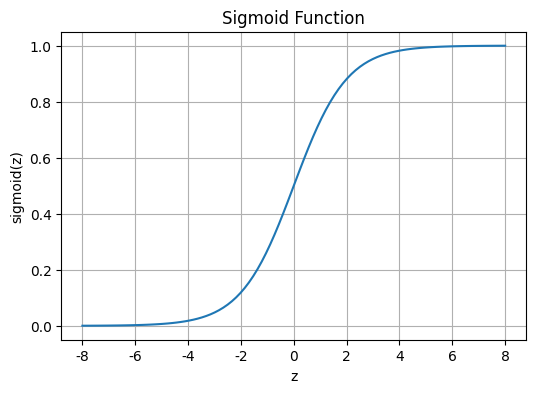

sigmoid(-2), sigmoid(0), sigmoid(2): [0.119 0.5   0.881]


In [11]:
def sigmoid(z):
    z = np.clip(z, -30, 30)     # 너무 작은 값은 -30으로, 너무 큰 값은 30으로 처리(torch에서도 동일하게 작동)
    return 1 / (1 + np.exp(-z))

z_values = np.linspace(-8, 8, 100)
plt.plot(z_values, sigmoid(z_values))
plt.title("Sigmoid Function")
plt.xlabel("z")
plt.ylabel("sigmoid(z)")
plt.grid(True)
plt.show()

print("sigmoid(-2), sigmoid(0), sigmoid(2):", np.round(sigmoid(np.array([-2, 0, 2])), 3))


## 5) 실습 2: 이진분류 모델 학습하기

* 공부 시간과 복습 횟수로 “통과 여부”를 예측하는 작은 데이터를 만듭니다.
* 손실 함수는 Binary Cross Entropy(BCE)를 사용합니다.

![스크린샷 2026-05-26 11-25-22.png](<attachment:스크린샷 2026-05-26 11-25-22.png>)

* y: 실제 정답
* p: 모델이 예측한 확률(0~1 사이의 값)
* 맨 앞 음수: 로그 계산 결과 나오는 음수를 양수로 바꾸는 장치

====================== 정답값 ======================
[0 0 0 0 0 0 0 0 1 1 1 1 1 1]
==================== 입력 데이터 ====================
[[1.  0. ]
 [1.5 1. ]
 [2.  0. ]
 [2.5 1. ]
 [3.  1. ]
 [3.2 2. ]
 [3.5 1. ]
 [4.  2. ]
 [4.5 2. ]
 [5.  3. ]
 [5.5 2. ]
 [6.  3. ]
 [6.5 4. ]
 [7.  4. ]]
==================== 표준화 된 입력 데이터 ====================
[[-1.62184615 -1.49120227]
 [-1.34628976 -0.6882472 ]
 [-1.07073338 -1.49120227]
 [-0.79517699 -0.6882472 ]
 [-0.51962061 -0.6882472 ]
 [-0.40939806  0.11470787]
 [-0.24406423 -0.6882472 ]
 [ 0.03149216  0.11470787]
 [ 0.30704854  0.11470787]
 [ 0.58260493  0.91766294]
 [ 0.85816131  0.11470787]
 [ 1.1337177   0.91766294]
 [ 1.40927408  1.720618  ]
 [ 1.68483046  1.720618  ]]
학습된 w: [6.028 2.631]
학습된 b: -1.312
최종 BCE: 0.0566


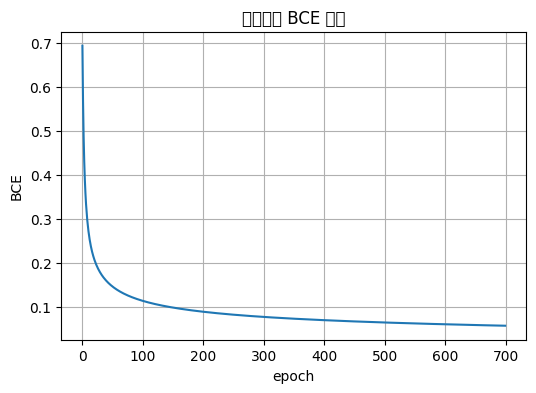

In [13]:
rng = np.random.default_rng(11)
hours = np.array([1, 1.5, 2, 2.5, 3, 3.2, 3.5, 4, 4.5, 5, 5.5, 6, 6.5, 7], dtype=float)
reviews = np.array([0, 1, 0, 1, 1, 2, 1, 2, 2, 3, 2, 3, 4, 4], dtype=float)
score_signal = 0.9 * hours + 0.8 * reviews + rng.normal(0, 0.35, size=hours.shape)
y = (score_signal >= 5.2).astype(int)
print("="*22, "정답값", "="*22)
print(y)

X_raw = np.column_stack([hours, reviews])
print("="*20, "입력 데이터", "="*20)
print(X_raw)
X_mean = X_raw.mean(axis=0)
X_std = X_raw.std(axis=0)
X = (X_raw - X_mean) / X_std
print("="*20, "표준화 된 입력 데이터", "="*20)
print(X)
print("="*59)

w = np.zeros(2)
b = 0.0
lr = 0.4
losses = []

for epoch in range(700):
    logits = X @ w + b
    proba = sigmoid(logits)
    loss = -np.mean(y * np.log(proba + 1e-9) + (1 - y) * np.log(1 - proba + 1e-9)) # BCE Loss
    losses.append(loss)

    grad_logits = proba - y
    grad_w = X.T @ grad_logits / len(y)
    grad_b = grad_logits.mean()
    w -= lr * grad_w
    b -= lr * grad_b

print("학습된 w:", np.round(w, 3))
print("학습된 b:", round(b, 3))
print("최종 BCE:", round(losses[-1], 4))

plt.plot(losses)
plt.title("이진분류 BCE 손실")
plt.xlabel("epoch")
plt.ylabel("BCE")
plt.grid(True)
plt.show()


## 5) 실습 3: 평가 지표 계산하기

확률을 라벨로 바꾼 뒤, 어떤 종류의 정답/오답이 생겼는지 확인합니다.


### 5-1) 혼동행렬(Confusion Matrix)

![image-2.png](https://velog.velcdn.com/images/jjw9599/post/f24251a1-9f89-4fad-a2b7-ad6e22171a98/image.png)

- TP (True Positive): 모델이 Positive라고 예측했고, 실제 값도 Positive.(정답)

- TN (True Negative): 모델이 Negative라고 예측했고, 실제 값도 Negative.(정답)

- FP (False Positive): 모델이 Positive라고 예측했는데, 실제 값은 Negative.

- FN (False Negative): 모델이 Negative라고 예측했는데, 실제 값은 Positive.

### 5-2) 정확도(Accuracy)

- 의미: 전체 예측 중 정답을 맞힌 비율. 가장 직관적인 지표.

- 계산식: (TP + TN) / (TP + TN + FP + FN)

- 장점: 이해하기 쉽고, 데이터 클래스가 균등하게 분포되어 있을 때 유용.

- 단점: 데이터가 불균형(imbalanced)할 때 성능을 심각하게 왜곡. (예: 99%가 정상이고 1%가 암인 데이터에서 모델이 전부 '정상'으로 예측해도 정확도는 99%가 나옴)



### 5-3) 정밀도(Precision)

- 의미: 모델이 "Positive"라고 예측한 것들 중, 실제로 Positive였던 것의 비율.

- 계산식: TP / (TP + FP)

- 사용 용도: FP를 낮추는 것이 중요할 때 사용됨.

    * 예시: 스팸 메일 분류. 일반 메일(Negative)을 스팸(Positive)으로 잘못 예측(FP)하면 중요한 메일을 놓치게 되므로, 정밀도가 높아야 합니다.

### 5-4) 재현율(Recall)

- 의미: 실제 정답이 Positive인 데이터 중, 모델이 Positive라고 예측한 비율.

- 계산식: TP / (TP + FN)

- 사용 용도: FN을 낮추는 것이 중요할 때 사용됨.

    * 예시: 암 진단 모델. 실제 암 환자(Positive)를 정상(Negative)으로 잘못 예측(FN)하면 치명적이므로, 재현율이 높아야 함. (다른 병이나 정상을 암으로 오진하더라도, 실제 암을 놓치면 안 됨)

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48373 (\N{HANGUL SYLLABLE BOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54943 (\N{HANGUL SYLLABLE HOES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45936 (\N{HANGUL SYLLABLE DE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


Confusion Matrix [[TN, FP], [FN, TP]]
[[8 0]
 [0 6]]
accuracy: 1.0
precision: 1.0
recall: 1.0
f1: 1.0


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44277 (\N{HANGUL SYLLABLE GONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48512 (\N{HANGUL SYLLABLE BU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr

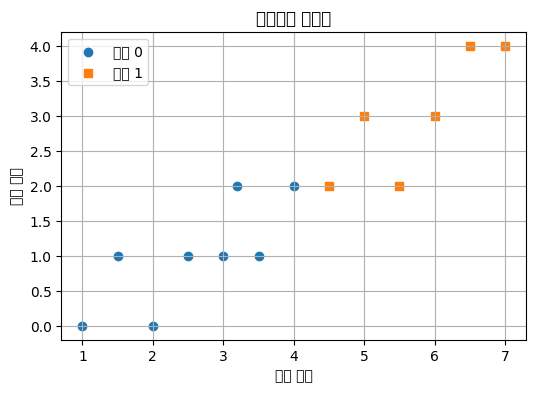

In [4]:
proba = sigmoid(X @ w + b)
threshold = 0.5
pred = (proba >= threshold).astype(int)

tp = int(((pred == 1) & (y == 1)).sum())
tn = int(((pred == 0) & (y == 0)).sum())
fp = int(((pred == 1) & (y == 0)).sum())
fn = int(((pred == 0) & (y == 1)).sum())

accuracy = (tp + tn) / len(y)
precision = tp / (tp + fp + 1e-9)
recall = tp / (tp + fn + 1e-9)
f1 = 2 * precision * recall / (precision + recall + 1e-9)

print("Confusion Matrix [[TN, FP], [FN, TP]]")
print(np.array([[tn, fp], [fn, tp]]))
print("accuracy:", round(accuracy, 3))
print("precision:", round(precision, 3))
print("recall:", round(recall, 3))
print("f1:", round(f1, 3))

plt.scatter(hours[y == 0], reviews[y == 0], label="정답 0", marker="o")
plt.scatter(hours[y == 1], reviews[y == 1], label="정답 1", marker="s")
plt.title("이진분류 데이터")
plt.xlabel("공부 시간")
plt.ylabel("복습 횟수")
plt.legend()
plt.grid(True)
plt.show()


## 6) TODO 실습 1: PyTorch로 이진분류 선형모델 학습하기

PyTorch에서는 이진분류에서 `BCEWithLogitsLoss`를 자주 씁니다. 이 손실함수는 sigmoid와 BCE 계산을 안정적으로 묶어서 처리합니다.  
그래서 모델은 sigmoid를 통과하기 전 점수인 logit을 출력하고, 손실함수에는 logit을 그대로 넣습니다.


In [20]:
import torch

torch.manual_seed(11)
torch_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_tensor = torch.tensor(X, dtype=torch.float32, device=torch_device)
y_tensor = torch.tensor(y.reshape(-1, 1), dtype=torch.float32, device=torch_device)

# TO-DO: 입력 차원이 2, 출력 차원이 1인 Linear 층 모델 선언하기. Device 설정은 torch_device로 설정
binary_model = torch.nn.Linear(2, 1, device=torch_device)

bce_loss_fn = torch.nn.BCEWithLogitsLoss()
binary_optimizer = torch.optim.SGD(binary_model.parameters(), lr=0.3)

# binary_model을 학습시키는 코드 작성
for epoch in range(120):
    binary_model.train()
    binary_optimizer.zero_grad()
    outputs = binary_model(X_tensor)
    torch_loss = bce_loss_fn(outputs, y_tensor)
    torch_loss.backward()
    binary_optimizer.step()

with torch.no_grad():
    torch_logits = binary_model(X_tensor)
    torch_proba = torch.sigmoid(torch_logits).cpu().numpy().ravel()
    torch_pred = (torch_proba >= 0.5).astype(int)

print("마지막 PyTorch BCE:", round(float(torch_loss.detach().cpu()), 4))
print("PyTorch 정확도:", round(float((torch_pred == y).mean()), 3))
print("처음 5개 확률:", np.round(torch_proba[:5], 3))


마지막 PyTorch BCE: 0.1217
PyTorch 정확도: 1.0
처음 5개 확률: [0.001 0.005 0.002 0.02  0.038]


## 7) TODO 실습 2: TP, FP, FN 계산하기 & threshold 값 바꿔보기

NumPy 모델과 마찬가지로 PyTorch 모델도 확률을 만든 뒤 threshold로 라벨을 결정합니다.


In [46]:
# TODO: 0.3, 0.5, 0.7 등으로 바꿔 precision과 recall을 비교하세요.
torch_threshold = 0.5
# 커지면 -> recall 값 감소 , precision 값 증가

torch_todo_pred = (torch_proba >= torch_threshold).astype(int)

# True Positive 계산
torch_tp = ((torch_todo_pred == 1) & (y == 1)).sum().item()

# False Positive 계산
torch_fp = ((torch_todo_pred == 1) & (y == 0)).sum().item()

# False Negative 계산
torch_fn = ((torch_todo_pred == 0) & (y == 1)).sum().item()

torch_precision = torch_tp / (torch_tp + torch_fp + 1e-9)
torch_recall = torch_tp / (torch_tp + torch_fn + 1e-9)

print("torch_threshold:", torch_threshold)
print("precision:", round(torch_precision, 3))
print("recall:", round(torch_recall, 3))


torch_threshold: 0.5
precision: 1.0
recall: 1.0


## 6) TODO 실습 3: 새 수강생 통과 확률 예측하기

공부 시간과 복습 횟수를 바꿔 예측 확률을 확인하세요.


In [ ]:
hours = np.array([1, 1.5, 2, 2.5, 3, 3.2, 3.5, 4, 4.5, 5, 5.5, 6, 6.5, 7], dtype=float)
reviews = np.array([0, 1, 0, 1, 1, 2, 1, 2, 2, 3, 2, 3, 4, 4], dtype=float)
score_signal = 0.9 * hours + 0.8 * reviews + rng.normal(0, 0.35, size=hours.shape)
y = (score_signal >= 5.2).astype(int)

In [58]:
# TODO 2: 아래 값을 수정해 여러 수강생 상황을 예측해 보세요.
new_hours = 4.0
new_reviews = 2.0

# 새로운 수강생 데이터를 표준화(standardization)
new_X_raw = np.array([new_hours, new_reviews])
new_X = (new_X_raw - X_mean) / X_std
new_X_tensor = torch.tensor(new_X, dtype=torch.float32, device=torch_device)

# 새로운 통과 확률 결과 계산
binary_model.eval()
with torch.no_grad():
    new_logits = binary_model(new_X_tensor)
    new_proba = torch.sigmoid(new_logits)

print("통과 확률:", round(float(new_proba[0]), 3))
print("예측 라벨:", int(new_proba[0] >= 0.5))


통과 확률: 0.511
예측 라벨: 1


## 7) 미니 퀴즈

1. MSE가 MAE보다 이상치에 더 민감한 이유는 무엇인가요?
- MSE는 예측값과 실제값의 오차를 제곱하여 계산한다. 따라서 실제값과 차이가 큰 이상치에 더 큰 패널티를 부여하기 때문에 더 민감하다.
2. sigmoid 함수의 출력 범위는 어디부터 어디까지인가요?
- 0부터 1 사이의 실수값을 출력한다. (prob, 확률값으로 해석 가능)
3. `BCEWithLogitsLoss`에는 sigmoid 적용 전 값과 적용 후 확률 중 무엇을 넣나요?
- sigmoid 전 값인 logits(예측값)를 입력한다. BCEWithLogitsLoss 내부적으로 sigmoid 함수와 BCELoss를 함께 수행한다.
4. threshold를 높이면 일반적으로 precision과 recall은 어떻게 달라질 수 있나요?
- threshold가 높아지면, Positive로 예측하는 기준이 엄격해져 positive 예측 수가 감소한다.
- precision은 증가한다.
- Recall은 감소한다.
5. false negative가 중요한 문제 상황의 예를 하나 들어보세요.
- 정상으로 예측하면 치명적인 문제가 발생하는 경우
- 암 진단 상황


## 8) 오늘의 정리

- 손실함수는 학습 방향을 정하는 기준입니다.
- PyTorch 이진분류에서는 `Linear → logits → BCEWithLogitsLoss` 흐름을 자주 씁니다.
- 이진분류는 확률을 만들고, threshold로 라벨을 결정합니다.
- accuracy만 보면 놓치는 문제가 있어 precision, recall, F1을 함께 확인합니다.
